# Malzbier Brahma — MACO Gerado: Análise dos 3 Cenários de Demanda

| Cenário | Descrição |
|---|---|
| **① Pré-demanda** | Cenário Divulgado — demanda original sem reajuste |
| **② Pós-demanda (+30%)** | Nova Demanda bruta — aumento de 30% nas GEOs |
| **③ Pós-demanda c/ BIAS −9%** | Nova Demanda ajustada — desconta superestimação histórica |
| **④ Pós-transporte** | Cenário ③ após dedução do custo de frete rodo SP→NENO |

> **MACO Líquido = Demanda × R\$285/HL − Custo Frete**  
> Frete rodo W0: 15.103 HL chegada × custo/HL ÷ 0,95 (avaria) — CDR BA (NE Sul) e PB (demais)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore')

# ── Paleta ────────────────────────────────────────────────────────────────────
BG  = '#0f1117'; AX  = '#1a1d27'; GR  = '#2e3145'; TXT = '#e0e0e0'
C1  = '#4fc3f7'   # azul  — ① Pré-demanda
C2  = '#f06292'   # rosa  — ② Pós +30%
C3  = '#ffb74d'   # amber — ③ Pós BIAS −9%
C4  = '#a5d6a7'   # verde — ④ Pós Transporte
CPOS = '#a5d6a7'; CNEG = '#ef9a9a'; CDOI = '#ffd54f'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': AX, 'axes.edgecolor': GR,
    'axes.labelcolor': TXT, 'xtick.color': '#b0b0b0', 'ytick.color': '#b0b0b0',
    'text.color': TXT, 'grid.color': GR, 'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.family': 'DejaVu Sans', 'axes.titlesize': 11, 'axes.labelsize': 10,
})

SEMANAS = ['W0', 'W1', 'W2', 'W3']
XTICK   = ['W0\n02/02', 'W1\n09/02', 'W2\n16/02', 'W3\n23/02']
XP      = np.arange(4)

# ═══════════════════════════════════════════════════════════════════════════════
# DADOS — extraídos da planilha Analise_LongNeck_WSNP (Cenário Divulgado /
#         Nova Demanda / Custos de transferência)
# ═══════════════════════════════════════════════════════════════════════════════

DEM_DIV_TOT  = np.array([10448.676,  11250.594,   8005.806,   9228.960])
DEM_ND_TOT   = np.array([13583.2788, 14625.7722, 10407.5478, 11997.6480])

EF_DIV  = np.array([13386.9833, 11213.5623, 23780.1538, 14551.2811])
EF_ND   = np.array([10252.3805,  4626.7813, 14739.6310,  2742.0703])

SUF_DIV = np.array([ 7.139347,  8.404072, 15.460130,  9.460187])
SUF_ND  = np.array([ 4.205883,  2.667361,  7.371260,  1.371304])

CABO_BA = 84.579425; CABO_PB = 95.328283
RODO_BA = CABO_BA * 1.6; RODO_PB = CABO_PB * 1.6
MACO_U  = 285.0; CPROD = 149.0
BIAS    = 1.09; AVARIA = 0.95; DOI_MIN = 12

TRANSF_W0_CHEGADA = 15103.0
TRANSF_W0_EMB_BA  = 3803.0  / AVARIA
TRANSF_W0_EMB_PB  = 12095.0 / AVARIA
CUSTO_FRETE_TOTAL = TRANSF_W0_EMB_BA * RODO_BA + TRANSF_W0_EMB_PB * RODO_PB

# ── Derivações ────────────────────────────────────────────────────────────────
DEM_BIAS_TOT = DEM_ND_TOT / BIAS

# MACO bruto semanal por cenário
MS_DIV  = DEM_DIV_TOT  * MACO_U
MS_ND   = DEM_ND_TOT   * MACO_U
MS_BIAS = DEM_BIAS_TOT * MACO_U

# ④ Pós-transporte: frete one-off deduzido em W0
MS_TRANSP        = MS_BIAS.copy().astype(float)
MS_TRANSP[0]    -= CUSTO_FRETE_TOTAL

# DOI pós-transporte:
#   W0 — lote ainda em trânsito → igual ao ②
#   W1+ — estoque recebe +TRANSF_W0_CHEGADA HL
SUF_TRANSP     = np.zeros(4)
SUF_TRANSP[0]  = SUF_ND[0]
for _wi in range(1, 4):
    SUF_TRANSP[_wi] = (EF_ND[_wi] + TRANSF_W0_CHEGADA) / (DEM_BIAS_TOT[_wi] / 7)

# Totais de MACO
MACO_BRUTO_DIV  = DEM_DIV_TOT.sum()  * MACO_U
MACO_BRUTO_ND   = DEM_ND_TOT.sum()   * MACO_U
MACO_BRUTO_BIAS = DEM_BIAS_TOT.sum() * MACO_U
MACO_LIQ_DIV    = MACO_BRUTO_DIV
MACO_LIQ_ND     = MACO_BRUTO_ND   - CUSTO_FRETE_TOTAL
MACO_LIQ_BIAS   = MACO_BRUTO_BIAS - CUSTO_FRETE_TOTAL

FMT_M = mticker.FuncFormatter(lambda v, _: f'R${v/1e6:.1f}M')
FMT_HL = mticker.FuncFormatter(lambda v, _: f'{v:,.0f}')

print(f"{'Cenário':<32} {'Dem.(HL)':>10}  {'MACO Bruto':>12}  {'Frete':>10}  {'MACO Líquido':>12}")
print('-'*72)
for lbl, dem, bruto, frete, liq in [
    ('① Pré-demanda (Divulgado)',    DEM_DIV_TOT.sum(),  MACO_BRUTO_DIV,  0,                 MACO_LIQ_DIV),
    ('② Pós-demanda +30% (s/BIAS)', DEM_ND_TOT.sum(),   MACO_BRUTO_ND,   CUSTO_FRETE_TOTAL, MACO_LIQ_ND),
    ('③ Pós-demanda c/ BIAS −9%',   DEM_BIAS_TOT.sum(), MACO_BRUTO_BIAS, CUSTO_FRETE_TOTAL, MACO_LIQ_BIAS),
    ('④ Pós-transporte (=③ líq.)',  DEM_BIAS_TOT.sum(), MACO_BRUTO_BIAS, CUSTO_FRETE_TOTAL, MACO_LIQ_BIAS),
]:
    print(f'{lbl:<32} {dem:>9,.0f}HL  R${bruto:>10,.0f}  R${frete:>8,.0f}  R${liq:>10,.0f}')
print(f'\nCusto frete: R$ {CUSTO_FRETE_TOTAL:,.0f}  |  BA: {TRANSF_W0_EMB_BA:,.0f} HL × R${RODO_BA:.2f}  |  PB: {TRANSF_W0_EMB_PB:,.0f} HL × R${RODO_PB:.2f}')


Cenário                            Dem.(HL)    MACO Bruto       Frete  MACO Líquido
------------------------------------------------------------------------
① Pré-demanda (Divulgado)           38,934HL  R$11,096,200  R$       0  R$11,096,200
② Pós-demanda +30% (s/BIAS)         50,614HL  R$14,425,060  R$2,483,623  R$11,941,437
③ Pós-demanda c/ BIAS −9%           46,435HL  R$13,234,000  R$2,483,623  R$10,750,377
④ Pós-transporte (=③ líq.)          46,435HL  R$13,234,000  R$2,483,623  R$10,750,377

Custo frete: R$ 2,483,623  |  BA: 4,003 HL × R$135.33  |  PB: 12,732 HL × R$152.53


---
## 1. Demanda NENO — Comparativo dos 3 Cenários por Semana


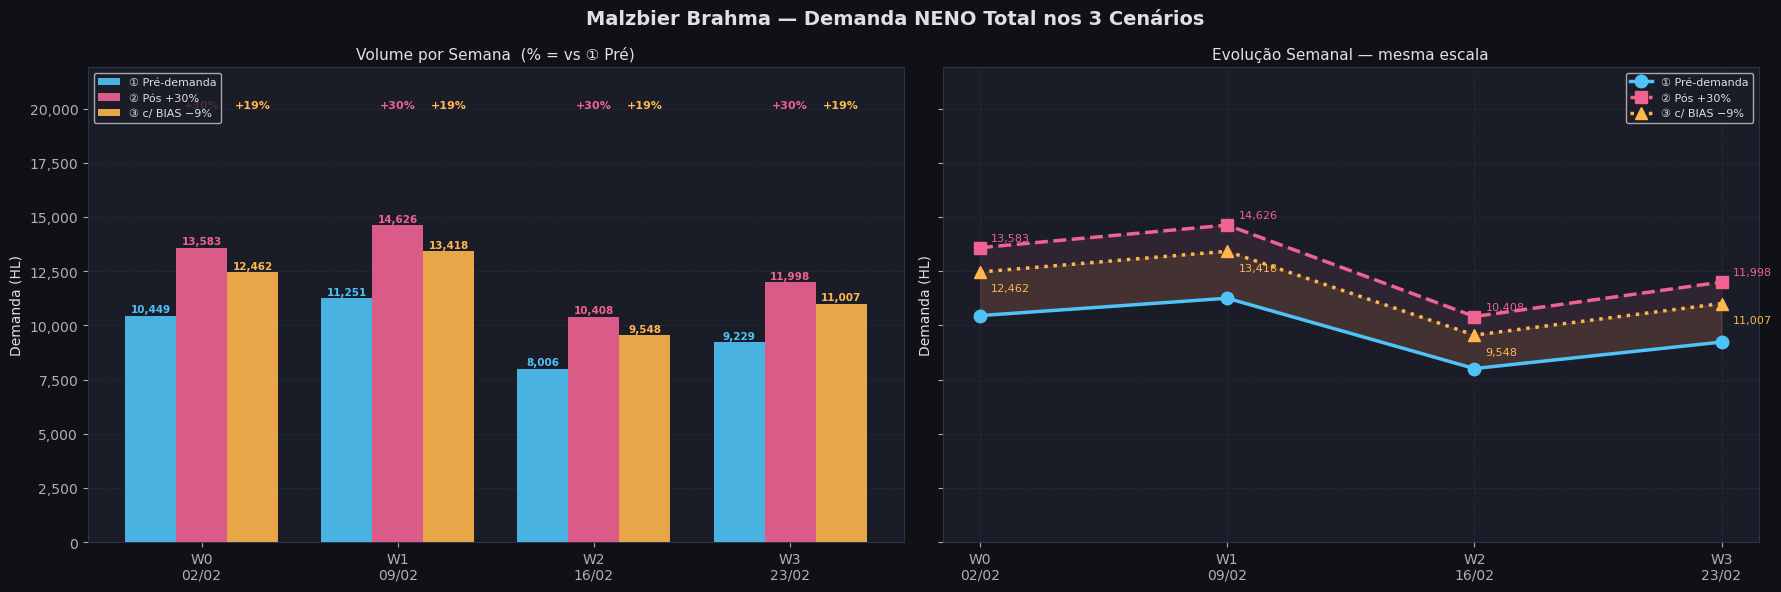


Semana      ① Pré    ② Pós+30%    ③ BIAS−9%        Δ②−①        Δ③−①
--------------------------------------------------------------------
W0       10,448.7     13,583.3     12,461.7    +3,134.6    +2,013.0
W1       11,250.6     14,625.8     13,418.1    +3,375.2    +2,167.5
W2        8,005.8     10,407.5      9,548.2    +2,401.7    +1,542.4
W3        9,229.0     11,997.6     11,007.0    +2,768.7    +1,778.1
--------------------------------------------------------------------
TOTAL    38,934.0     50,614.2     46,435.1   +11,680.2    +7,501.1


In [2]:
# Escala Y única para ambos os painéis
_ymax_dem = DEM_ND_TOT.max() * 1.28

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier Brahma — Demanda NENO Total nos 3 Cenários',
             fontsize=14, fontweight='bold', color=TXT)

# ── barras ────────────────────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor(AX)
bw = 0.26
b1 = ax.bar(XP - bw, DEM_DIV_TOT,  bw, color=C1, alpha=0.9, label='① Pré-demanda', zorder=3)
b2 = ax.bar(XP,      DEM_ND_TOT,   bw, color=C2, alpha=0.9, label='② Pós +30%',    zorder=3)
b3 = ax.bar(XP + bw, DEM_BIAS_TOT, bw, color=C3, alpha=0.9, label='③ c/ BIAS −9%', zorder=3)
for bars, vals, cor in [(b1,DEM_DIV_TOT,C1),(b2,DEM_ND_TOT,C2),(b3,DEM_BIAS_TOT,C3)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+_ymax_dem*0.008,
                f'{v:,.0f}', ha='center', fontsize=7.5, color=cor, fontweight='bold')
for i in range(4):
    pct2 = (DEM_ND_TOT[i]   - DEM_DIV_TOT[i]) / DEM_DIV_TOT[i] * 100
    pct3 = (DEM_BIAS_TOT[i] - DEM_DIV_TOT[i]) / DEM_DIV_TOT[i] * 100
    ax.text(i,      _ymax_dem * 1.07, f'{pct2:+.0f}%', ha='center', fontsize=8, color=C2, fontweight='bold')
    ax.text(i + bw, _ymax_dem * 1.07, f'{pct3:+.0f}%', ha='center', fontsize=8, color=C3, fontweight='bold')
ax.set_ylim(0, _ymax_dem * 1.17)
ax.set_xticks(XP); ax.set_xticklabels(XTICK)
ax.set_ylabel('Demanda (HL)'); ax.set_title('Volume por Semana  (% = vs ① Pré)')
ax.legend(fontsize=8); ax.grid(axis='y', zorder=0)
ax.yaxis.set_major_formatter(FMT_HL)

# ── linhas — mesma escala pelo sharey ─────────────────────────────────────────
ax2 = axes[1]; ax2.set_facecolor(AX)
ax2.plot(XP, DEM_DIV_TOT,  'o-',  color=C1, lw=2.5, ms=9, label='① Pré-demanda', zorder=4)
ax2.plot(XP, DEM_ND_TOT,   's--', color=C2, lw=2.5, ms=9, label='② Pós +30%',    zorder=4)
ax2.plot(XP, DEM_BIAS_TOT, '^:',  color=C3, lw=2.5, ms=9, label='③ c/ BIAS −9%', zorder=4)
ax2.fill_between(XP, DEM_DIV_TOT, DEM_ND_TOT,   alpha=0.10, color=C2)
ax2.fill_between(XP, DEM_DIV_TOT, DEM_BIAS_TOT, alpha=0.10, color=C3)
for i in range(4):
    ax2.annotate(f'{DEM_ND_TOT[i]:,.0f}',   xy=(i,DEM_ND_TOT[i]),   xytext=(8,  5), textcoords='offset points', fontsize=8, color=C2)
    ax2.annotate(f'{DEM_BIAS_TOT[i]:,.0f}', xy=(i,DEM_BIAS_TOT[i]), xytext=(8,-14), textcoords='offset points', fontsize=8, color=C3)
ax2.set_xticks(XP); ax2.set_xticklabels(XTICK)
ax2.set_ylabel('Demanda (HL)'); ax2.set_title('Evolução Semanal — mesma escala')
ax2.legend(fontsize=8); ax2.grid(zorder=0)
ax2.yaxis.set_major_formatter(FMT_HL)

plt.tight_layout(); plt.show()

print(f"\n{'Semana':<6} {'① Pré':>10} {'② Pós+30%':>12} {'③ BIAS−9%':>12}  {'Δ②−①':>10}  {'Δ③−①':>10}")
print('-'*68)
for i, w in enumerate(SEMANAS):
    print(f"{w:<6} {DEM_DIV_TOT[i]:>10,.1f} {DEM_ND_TOT[i]:>12,.1f} {DEM_BIAS_TOT[i]:>12,.1f}"
          f"  {DEM_ND_TOT[i]-DEM_DIV_TOT[i]:>+10,.1f}  {DEM_BIAS_TOT[i]-DEM_DIV_TOT[i]:>+10,.1f}")
print('-'*68)
print(f"{'TOTAL':<6} {DEM_DIV_TOT.sum():>10,.1f} {DEM_ND_TOT.sum():>12,.1f} {DEM_BIAS_TOT.sum():>12,.1f}"
      f"  {DEM_ND_TOT.sum()-DEM_DIV_TOT.sum():>+10,.1f}  {DEM_BIAS_TOT.sum()-DEM_DIV_TOT.sum():>+10,.1f}")


---
## 2. MACO por Semana — Pré-demanda, Pós-demanda e Pós-transporte

> Gráfico de linhas comparando os **4 momentos** com a **mesma escala**.  
> ④ Pós-transporte = cenário ③ com o custo de frete (R$ 2,48M) deduzido em W0.


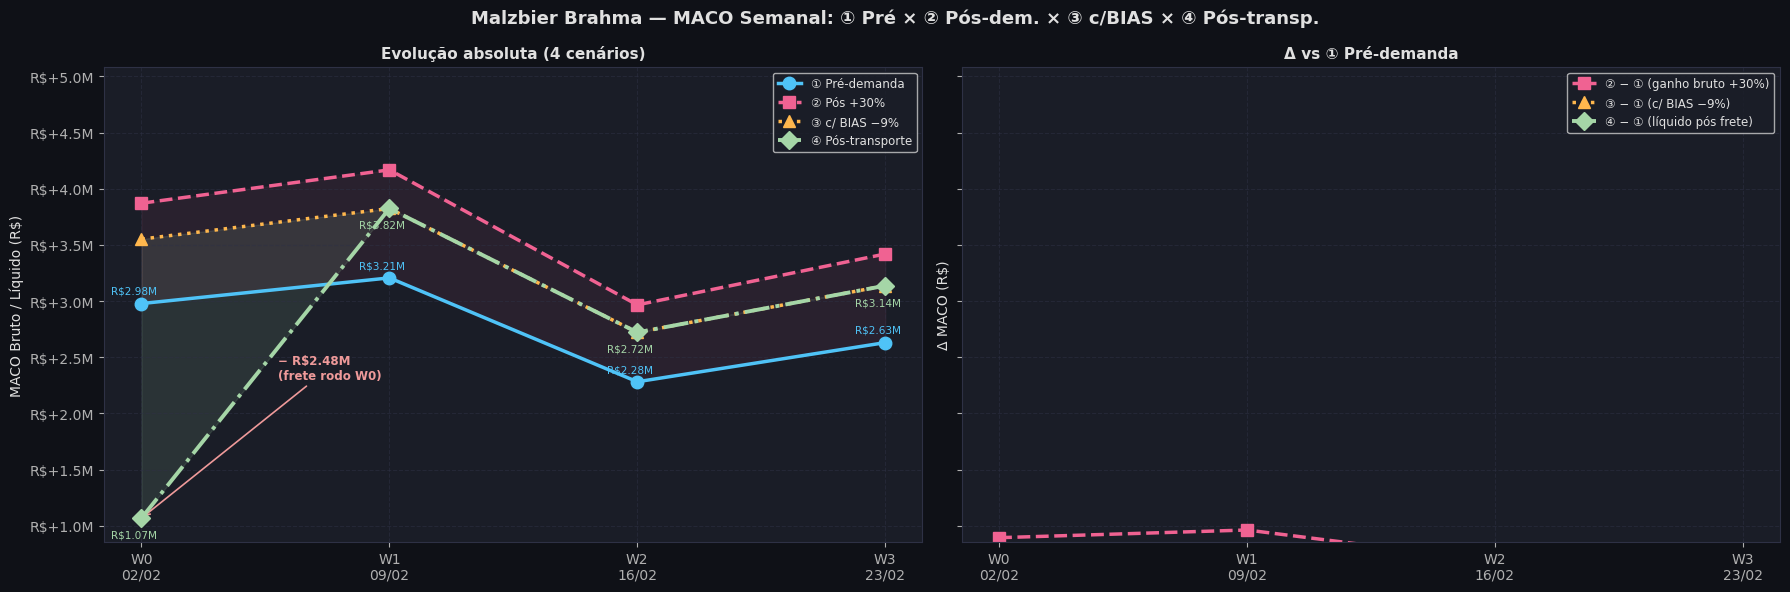

In [3]:
# Escala Y única: do mínimo (MS_TRANSP[0] pode ser baixo) ao máximo
_ymin_ms = MS_TRANSP.min() * 0.80
_ymax_ms = MS_ND.max() * 1.22

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier Brahma — MACO Semanal: ① Pré × ② Pós-dem. × ③ c/BIAS × ④ Pós-transp.',
             fontsize=13, fontweight='bold', color=TXT)

for ax, titulo, show_delta in [(axes[0], 'Evolução absoluta (4 cenários)', False),
                                (axes[1], 'Δ vs ① Pré-demanda',           True)]:
    ax.set_facecolor(AX)

    if not show_delta:
        ax.plot(XP, MS_DIV,   'o-',  color=C1, lw=2.5, ms=9, label='① Pré-demanda',     zorder=5)
        ax.plot(XP, MS_ND,    's--', color=C2, lw=2.5, ms=9, label='② Pós +30%',         zorder=5)
        ax.plot(XP, MS_BIAS,  '^:',  color=C3, lw=2.5, ms=9, label='③ c/ BIAS −9%',      zorder=5)
        ax.plot(XP, MS_TRANSP,'D-.', color=C4, lw=2.8, ms=9, label='④ Pós-transporte',   zorder=5)
        ax.fill_between(XP, MS_BIAS, MS_TRANSP, alpha=0.12, color=C4)
        ax.fill_between(XP, MS_DIV,  MS_ND,     alpha=0.07, color=C2)
        ax.axhline(0, color='#555', lw=0.8)
        # anotação do frete
        ax.annotate(
            f'− R${CUSTO_FRETE_TOTAL/1e6:.2f}M\n(frete rodo W0)',
            xy=(0, MS_TRANSP[0]),
            xytext=(0.55, (MS_BIAS[0]+MS_TRANSP[0])/2),
            fontsize=8.5, color=CNEG, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=CNEG, lw=1.2))
        for i in range(4):
            ax.annotate(f'R${MS_DIV[i]/1e6:.2f}M',  xy=(i,MS_DIV[i]),   xytext=(-22, 7),  textcoords='offset points', fontsize=7.5, color=C1)
            ax.annotate(f'R${MS_TRANSP[i]/1e6:.2f}M',xy=(i,MS_TRANSP[i]),xytext=(-22,-14), textcoords='offset points', fontsize=7.5, color=C4)
        ax.set_ylabel('MACO Bruto / Líquido (R$)')
        ax.yaxis.set_major_formatter(FMT_M)
        ax.legend(fontsize=8.5, loc='upper right')
    else:
        d2 = MS_ND     - MS_DIV
        d3 = MS_BIAS   - MS_DIV
        d4 = MS_TRANSP - MS_DIV
        ax.plot(XP, d2, 's--', color=C2, lw=2.5, ms=9, label='② − ① (ganho bruto +30%)')
        ax.plot(XP, d3, '^:',  color=C3, lw=2.5, ms=9, label='③ − ① (c/ BIAS −9%)')
        ax.plot(XP, d4, 'D-.', color=C4, lw=2.8, ms=9, label='④ − ① (líquido pós frete)')
        ax.axhline(0, color='#888', lw=1.2, ls='--')
        ax.fill_between(XP, 0, d4, where=(d4 >= 0), color=C4,   alpha=0.13)
        ax.fill_between(XP, 0, d4, where=(d4 <  0), color=CNEG, alpha=0.20)
        for i in range(4):
            sign = '+' if d4[i] >= 0 else ''
            ax.annotate(f'R${d4[i]/1e3:{sign}.0f}k',
                        xy=(i, d4[i]), xytext=(6, 7 if d4[i] >= 0 else -16),
                        textcoords='offset points', fontsize=8, color=C4, fontweight='bold')
        ax.set_ylabel('Δ MACO (R$)')
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v/1e6:+.1f}M'))
        ax.legend(fontsize=8.5)

    ax.set_ylim(_ymin_ms, _ymax_ms)
    ax.set_xticks(XP); ax.set_xticklabels(XTICK)
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.grid(zorder=0)

plt.tight_layout(); plt.show()


---
## 3. Decomposição do MACO — Waterfall (mesma escala Y)

> Os 3 waterfalls compartilham o **mesmo eixo Y** para permitir comparação direta.


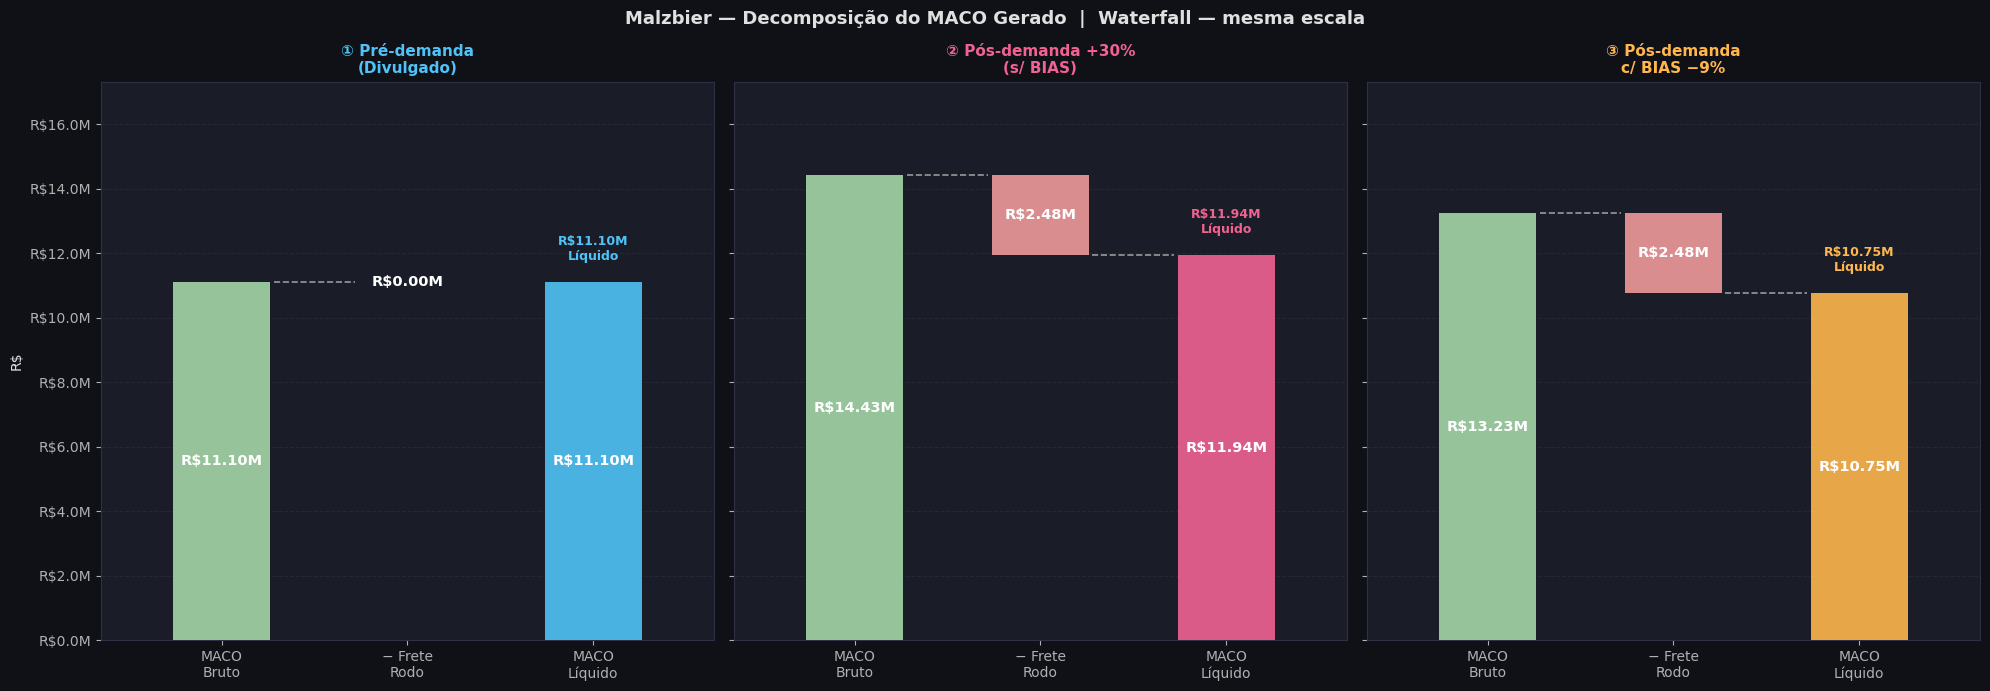

In [4]:
# Escala única: 0 até o maior MACO bruto × 1.20
_ymax_wf = max(MACO_BRUTO_DIV, MACO_BRUTO_ND, MACO_BRUTO_BIAS) * 1.20

fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier — Decomposição do MACO Gerado  |  Waterfall — mesma escala',
             fontsize=13, fontweight='bold', color=TXT)

_cenarios_wf = [
    ('① Pré-demanda\n(Divulgado)',    MACO_BRUTO_DIV,  0,                 MACO_LIQ_DIV,  C1),
    ('② Pós-demanda +30%\n(s/ BIAS)', MACO_BRUTO_ND,   CUSTO_FRETE_TOTAL, MACO_LIQ_ND,   C2),
    ('③ Pós-demanda\nc/ BIAS −9%',    MACO_BRUTO_BIAS, CUSTO_FRETE_TOTAL, MACO_LIQ_BIAS, C3),
]

for ax, (titulo, bruto, frete, liq, cor) in zip(axes, _cenarios_wf):
    ax.set_facecolor(AX)

    cats  = ['MACO\nBruto', '− Frete\nRodo', 'MACO\nLíquido']
    vals  = [bruto, -frete, liq]
    bases = [0,     bruto,  0]
    cbars = [CPOS,  CNEG,   cor]

    for xi, (val, base, cb) in enumerate(zip(vals, bases, cbars)):
        h   = abs(val)
        bot = base if val >= 0 else base + val
        ax.bar(xi, h, 0.52, bottom=bot, color=cb, alpha=0.90, zorder=3)
        mid = bot + h / 2
        # valor dentro da barra
        ax.text(xi, mid, f'R${abs(val)/1e6:.2f}M',
                ha='center', va='center', fontsize=10.5, fontweight='bold', color='white')
        # conector pontilhado entre barras
        if xi < 2 and val != 0:
            nxt = base + val
            ax.plot([xi+0.28, xi+0.72], [nxt, nxt], color='#999', lw=1.2, ls='--')

    # rótulo acima da barra líquida
    ax.text(2, liq + _ymax_wf * 0.04, f'R${liq/1e6:.2f}M\nLíquido',
            ha='center', fontsize=9, color=cor, fontweight='bold')

    ax.set_ylim(0, _ymax_wf)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(cats, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold', color=cor)
    if titulo.startswith('①'):
        ax.set_ylabel('R$')
    ax.yaxis.set_major_formatter(FMT_M)
    ax.set_xlim(-0.65, 2.65)
    ax.grid(axis='y', zorder=0)

plt.tight_layout(); plt.show()


---
## 4. MACO Total — Bruto, Frete e Líquido por Cenário


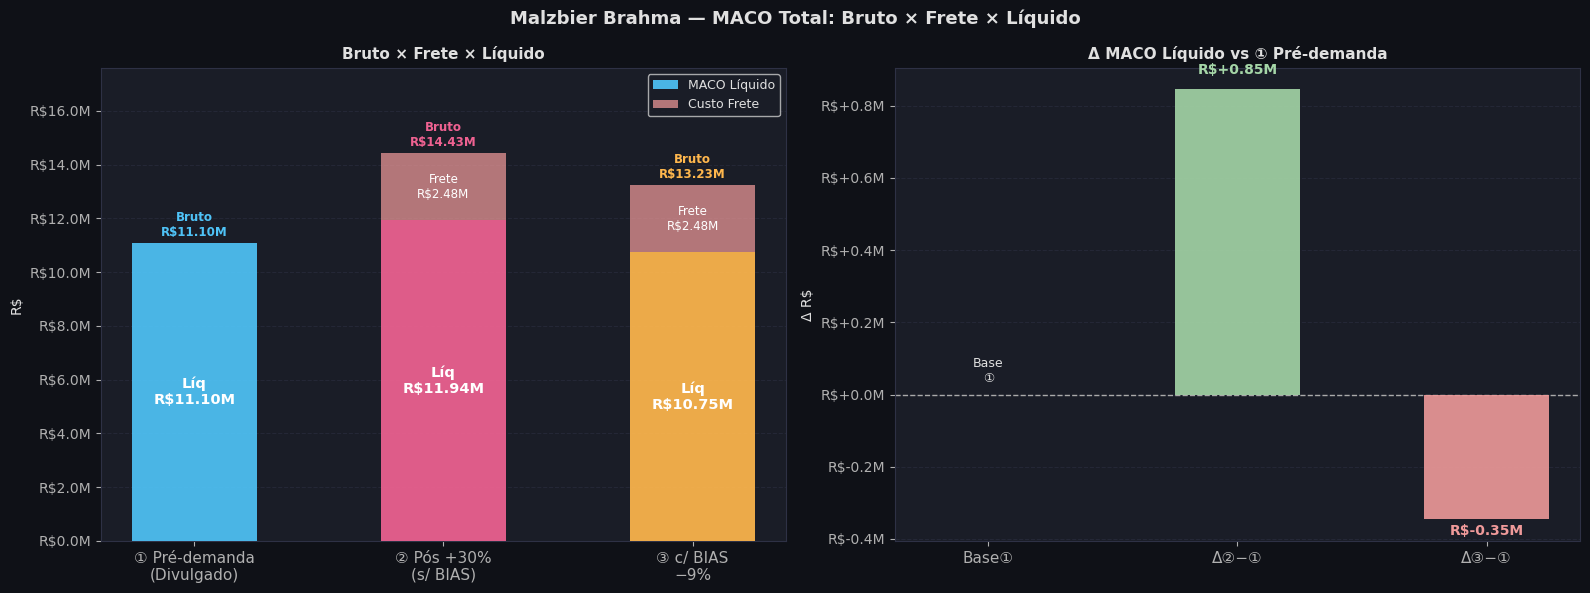

In [5]:
BRUTOS = [MACO_BRUTO_DIV,  MACO_BRUTO_ND,   MACO_BRUTO_BIAS]
FRETES = [0,               CUSTO_FRETE_TOTAL, CUSTO_FRETE_TOTAL]
LIQS   = [MACO_LIQ_DIV,   MACO_LIQ_ND,      MACO_LIQ_BIAS]
CORS3  = [C1, C2, C3]
LABS3  = ['① Pré-demanda\n(Divulgado)', '② Pós +30%\n(s/ BIAS)', '③ c/ BIAS\n−9%']
xp3    = np.arange(3)
_ymax_a = max(BRUTOS) * 1.22

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier Brahma — MACO Total: Bruto × Frete × Líquido',
             fontsize=13, fontweight='bold', color=TXT)

# ── empilhado ─────────────────────────────────────────────────────────────────
ax = axes[0]; ax.set_facecolor(AX)
ax.bar(xp3, LIQS,   0.50, color=CORS3, alpha=0.92, label='MACO Líquido', zorder=3)
ax.bar(xp3, FRETES, 0.50, bottom=LIQS, color=CNEG,  alpha=0.72, label='Custo Frete',  zorder=3)
for xi, (bruto, frete, liq, cor) in enumerate(zip(BRUTOS, FRETES, LIQS, CORS3)):
    ax.text(xi, bruto + _ymax_a*0.015, f'Bruto\nR${bruto/1e6:.2f}M',
            ha='center', fontsize=8.5, color=cor, fontweight='bold')
    ax.text(xi, liq/2, f'Líq\nR${liq/1e6:.2f}M',
            ha='center', va='center', fontsize=10.5, color='white', fontweight='bold')
    if frete > 0:
        ax.text(xi, liq + frete/2, f'Frete\nR${frete/1e6:.2f}M',
                ha='center', va='center', fontsize=8.5, color='white')
ax.set_xticks(xp3); ax.set_xticklabels(LABS3, fontsize=11)
ax.set_ylim(0, _ymax_a)
ax.set_title('Bruto × Frete × Líquido', fontsize=11, fontweight='bold')
ax.set_ylabel('R$'); ax.yaxis.set_major_formatter(FMT_M)
ax.legend(fontsize=9); ax.grid(axis='y', zorder=0)

# ── delta vs base ─────────────────────────────────────────────────────────────
ax2 = axes[1]; ax2.set_facecolor(AX)
deltas = [0, LIQS[1]-LIQS[0], LIQS[2]-LIQS[0]]
dcors  = [TXT, CPOS if deltas[1]>=0 else CNEG, CPOS if deltas[2]>=0 else CNEG]
ax2.bar(xp3, deltas, 0.50, color=dcors, alpha=0.90, zorder=3)
ax2.axhline(0, color='#aaa', lw=1, ls='--')
_mx_d = max(abs(d) for d in deltas) or 1
for xi, (v, c) in enumerate(zip(deltas, dcors)):
    if v != 0:
        off = _mx_d*0.05 if v >= 0 else -_mx_d*0.05
        ax2.text(xi, v+off, f'R${v/1e6:+.2f}M', ha='center', fontsize=10, fontweight='bold', color=c)
    else:
        ax2.text(xi, _mx_d*0.04, 'Base\n①', ha='center', fontsize=9, color=TXT)
ax2.set_xticks(xp3); ax2.set_xticklabels(['Base①', 'Δ②−①', 'Δ③−①'], fontsize=11)
ax2.set_title('Δ MACO Líquido vs ① Pré-demanda', fontsize=11, fontweight='bold')
ax2.set_ylabel('Δ R$')
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v/1e6:+.1f}M'))
ax2.grid(axis='y', zorder=0)

plt.tight_layout(); plt.show()


---
## 5. DOI por Semana — Pré-demanda × Pós-demanda × Pós-transporte

> Mesma escala Y nos dois painéis.  
> ④ Pós-transporte: W0 sem o lote (em trânsito), W1–W3 com +15.103 HL chegados.


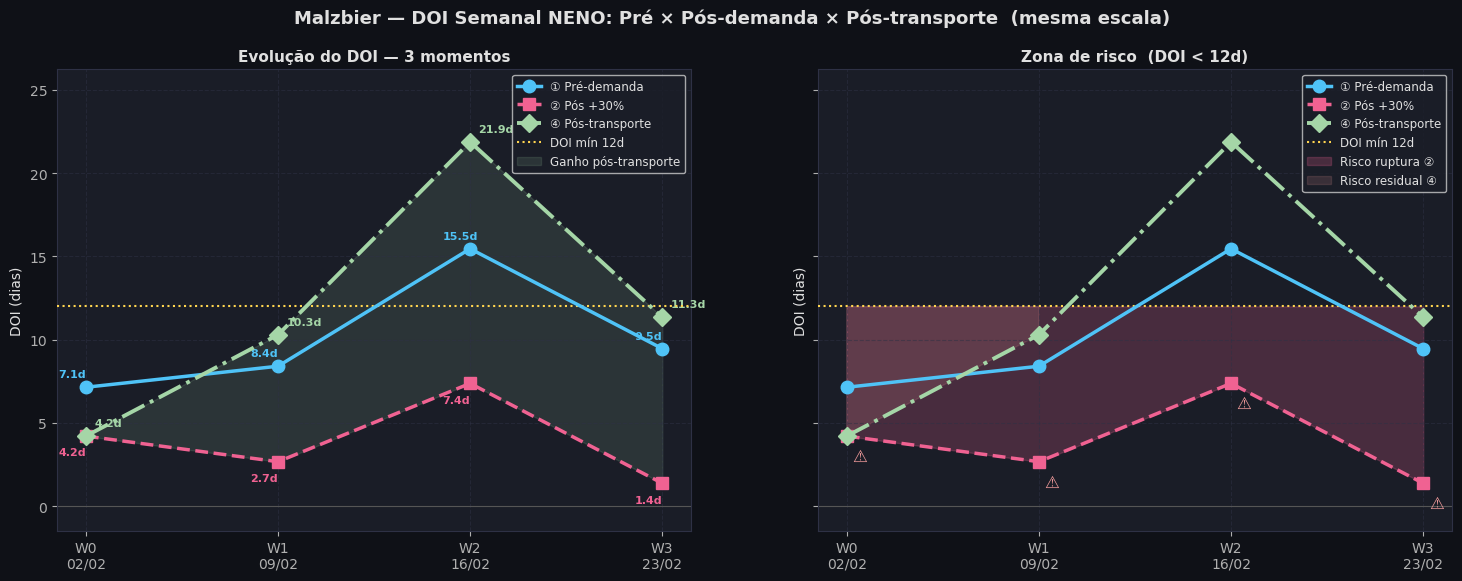

In [ ]:
_ymin_doi = min(SUF_ND.min(), -1.5)
_ymax_doi = max(SUF_TRANSP.max(), SUF_DIV.max()) * 1.20

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier — DOI Semanal NENO: Pré × Pós-demanda × Pós-transporte  (mesma escala)',
             fontsize=13, fontweight='bold', color=TXT)

for ax, titulo, show_areas in [
    (axes[0], 'Evolução do DOI — 3 momentos', True),
    (axes[1], 'Zona de risco  (DOI < 12d)',   False),
]:
    ax.set_facecolor(AX)
    ax.plot(XP, SUF_DIV,    'o-',  color=C1, lw=2.5, ms=9, zorder=5, label='① Pré-demanda')
    ax.plot(XP, SUF_ND,     's--', color=C2, lw=2.5, ms=9, zorder=5, label='② Pós +30%')
    ax.plot(XP, SUF_TRANSP, 'D-.', color=C4, lw=2.8, ms=9, zorder=5, label='④ Pós-transporte')
    ax.axhline(DOI_MIN, color=CDOI, lw=1.5, ls=':', zorder=4, label=f'DOI mín {DOI_MIN}d')
    ax.axhline(0,       color='#555', lw=0.8)

    if show_areas:
        ax.fill_between(XP, SUF_ND, SUF_TRANSP, alpha=0.13, color=C4, label='Ganho pós-transporte')
        for i in range(4):
            ax.annotate(f'{SUF_DIV[i]:.1f}d',    xy=(i,SUF_DIV[i]),    xytext=(-20,  7), textcoords='offset points', fontsize=8, color=C1, fontweight='bold')
            ax.annotate(f'{SUF_ND[i]:.1f}d',     xy=(i,SUF_ND[i]),     xytext=(-20,-14), textcoords='offset points', fontsize=8, color=C2, fontweight='bold')
            ax.annotate(f'{SUF_TRANSP[i]:.1f}d', xy=(i,SUF_TRANSP[i]), xytext=( 6,   7), textcoords='offset points', fontsize=8, color=C4, fontweight='bold')
    else:
        ax.fill_between(XP, SUF_ND,     DOI_MIN, where=(SUF_ND     < DOI_MIN), color=C2,   alpha=0.22, label='Risco ruptura ②')
        ax.fill_between(XP, SUF_TRANSP, DOI_MIN, where=(SUF_TRANSP < DOI_MIN), color=CNEG, alpha=0.15, label='Risco residual ④')
        for i, v in enumerate(SUF_ND):
            if v < DOI_MIN:
                ax.annotate('⚠', xy=(i,v), xytext=(4,-18),
                            textcoords='offset points', fontsize=12, color=CNEG, fontweight='bold')

    ax.set_ylim(_ymin_doi, _ymax_doi)
    ax.set_xticks(XP); ax.set_xticklabels(XTICK)
    ax.set_ylabel('DOI (dias)')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8.5, loc='upper right'); ax.grid(zorder=0)

plt.tight_layout(); plt.show()


---
## 6. Custo de Frete — Detalhamento por CDR e Modal


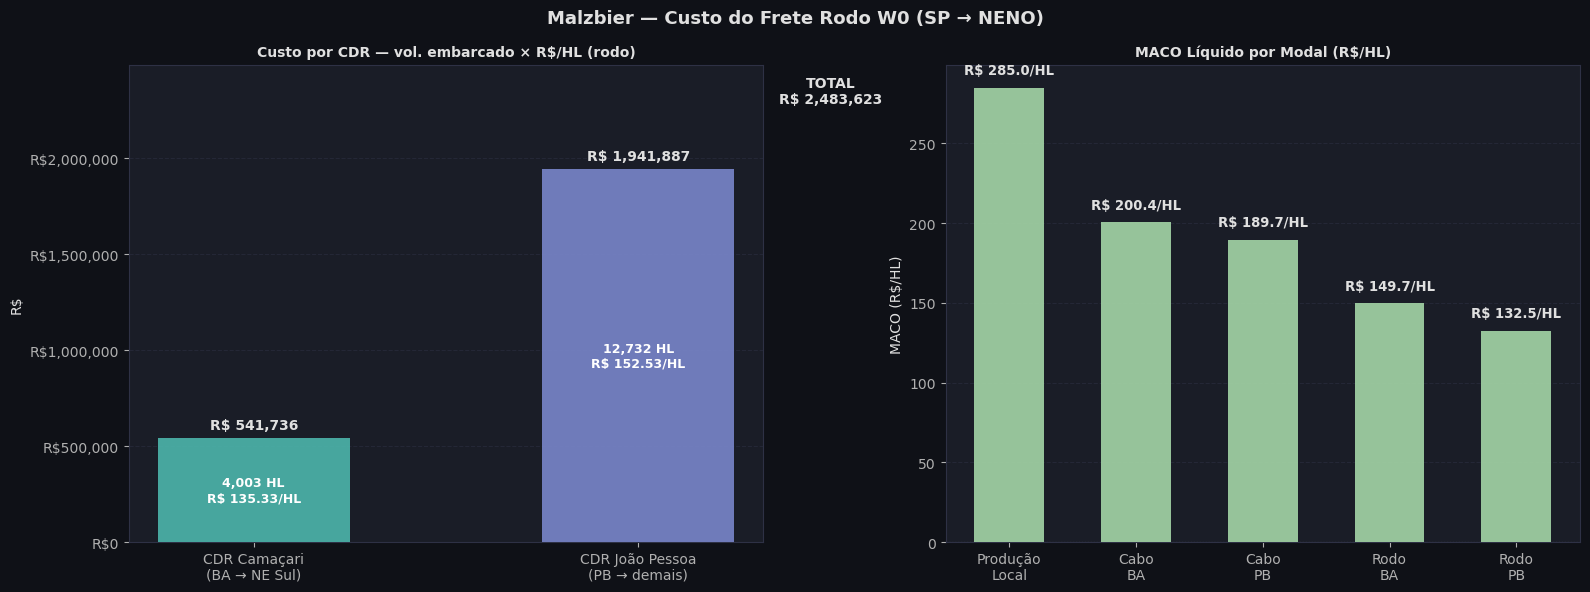


=== DETALHAMENTO CUSTO FRETE ===
  BA: 4,003.2 HL × R$135.33/HL = R$ 541,736
  PB: 12,731.6 HL × R$152.53/HL = R$ 1,941,887
  TOTAL:                              R$ 2,483,623
  (15,898 HL chegam de 16,735 HL embarcados — avaria 5%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor(BG)
fig.suptitle('Malzbier — Custo do Frete Rodo W0 (SP → NENO)',
             fontsize=13, fontweight='bold', color=TXT)

cdrs      = ['CDR Camaçari\n(BA → NE Sul)', 'CDR João Pessoa\n(PB → demais)']
vols_emb  = [TRANSF_W0_EMB_BA,   TRANSF_W0_EMB_PB]
custos_u  = [RODO_BA,             RODO_PB]
custos_t  = [v*c for v,c in zip(vols_emb, custos_u)]
cores_cdr = ['#4db6ac', '#7986cb']

ax = axes[0]; ax.set_facecolor(AX)
_ymax_c = max(custos_t) * 1.28
bars = ax.bar(cdrs, custos_t, 0.5, color=cores_cdr, alpha=0.90, zorder=3)
for bar, v, vol, cu in zip(bars, custos_t, vols_emb, custos_u):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+_ymax_c*0.02,
            f'R$ {v:,.0f}', ha='center', fontsize=10, fontweight='bold', color=TXT)
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()/2,
            f'{vol:,.0f} HL\nR$ {cu:.2f}/HL',
            ha='center', va='center', fontsize=9, color='white', fontweight='bold')
ax.text(1.5, _ymax_c*0.92, f'TOTAL\nR$ {CUSTO_FRETE_TOTAL:,.0f}',
        ha='center', fontsize=10, color=TXT, fontweight='bold')
ax.set_ylim(0, _ymax_c)
ax.set_title('Custo por CDR — vol. embarcado × R$/HL (rodo)', fontsize=10, fontweight='bold')
ax.set_ylabel('R$')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'R${v:,.0f}'))
ax.grid(axis='y', zorder=0)

ax2 = axes[1]; ax2.set_facecolor(AX)
modais  = ['Produção\nLocal', 'Cabo\nBA', 'Cabo\nPB', 'Rodo\nBA', 'Rodo\nPB']
macols  = [MACO_U, MACO_U-CABO_BA, MACO_U-CABO_PB, MACO_U-RODO_BA, MACO_U-RODO_PB]
cores_m = [CPOS if v >= 0 else CNEG for v in macols]
bars2   = ax2.bar(modais, macols, 0.55, color=cores_m, alpha=0.90, zorder=3)
ax2.axhline(0, color='#888', lw=0.8, ls=':')
_mx_m = max(macols)
for bar, v in zip(bars2, macols):
    yt = bar.get_height() + _mx_m*0.03 if v >= 0 else bar.get_height() - _mx_m*0.07
    ax2.text(bar.get_x()+bar.get_width()/2, yt,
             f'R$ {v:.1f}/HL', ha='center', fontsize=9.5, fontweight='bold', color=TXT)
ax2.set_title('MACO Líquido por Modal (R$/HL)', fontsize=10, fontweight='bold')
ax2.set_ylabel('MACO (R$/HL)'); ax2.grid(axis='y', zorder=0)

plt.tight_layout(); plt.show()

print(f'\n=== DETALHAMENTO CUSTO FRETE ===')
print(f'  BA: {TRANSF_W0_EMB_BA:,.1f} HL × R${RODO_BA:.2f}/HL = R$ {TRANSF_W0_EMB_BA*RODO_BA:,.0f}')
print(f'  PB: {TRANSF_W0_EMB_PB:,.1f} HL × R${RODO_PB:.2f}/HL = R$ {TRANSF_W0_EMB_PB*RODO_PB:,.0f}')
print(f'  TOTAL:                              R$ {CUSTO_FRETE_TOTAL:,.0f}')
print(f'  ({(TRANSF_W0_EMB_BA+TRANSF_W0_EMB_PB)*AVARIA:,.0f} HL chegam de {TRANSF_W0_EMB_BA+TRANSF_W0_EMB_PB:,.0f} HL embarcados — avaria 5%)')
